In [1]:
import pandas as pd

#Loading/Reading the csv
df=pd.read_csv("diabetes_prediction_dataset.csv")
print(df)
print("\n")

       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              6.6                  140        

In [2]:
#preprocess the data
#1. checking null values
print("Null values:")
print(df.isnull().any()) #column-wise 
print(df.isnull().any(axis=1)) #row-wise

Null values:
gender                 False
age                    False
hypertension           False
heart_disease          False
smoking_history        False
bmi                    False
HbA1c_level            False
blood_glucose_level    False
diabetes               False
dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool


In [3]:
#2.checking duplicated
print(df.duplicated())
print(df.drop_duplicates(inplace=True))
print(df)

0        False
1        False
2        False
3        False
4        False
         ...  
99995     True
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool
None
       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99994  Female  36.0             0              0         No Info  24.60   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0    

In [4]:
# 3. Normalise the blood glucose level
min=df['blood_glucose_level'].min()
max=df['blood_glucose_level'].max()

df['blood_glucose_level']=(df['blood_glucose_level']-min)/(max-min);
print(df['blood_glucose_level'])

0        0.272727
1        0.000000
2        0.354545
3        0.340909
4        0.340909
           ...   
99994    0.295455
99996    0.090909
99997    0.340909
99998    0.090909
99999    0.045455
Name: blood_glucose_level, Length: 96146, dtype: float64


In [5]:
# 4. Converting Categorial(Qualitative) to Ordinal Data(Quantitative)
df['gender']=df['gender'].map({
    'Male':1,
    'Female':0,
    'Other':2
})

df['smoking_history']=df['smoking_history'].map({
   'never':0,
    'No Info': 1,
    'not current': 2,
    'former': 3,
    'ever': 4,
    'current': 5  
})

print(df['gender'].head())
print(df['smoking_history'].head())

0    0
1    0
2    1
3    0
4    1
Name: gender, dtype: int64
0    0
1    1
2    0
3    5
4    5
Name: smoking_history, dtype: int64


In [6]:
#5. Identify outliers

numeric_cols=df.select_dtypes(include=['int64','float64']).columns

outliers_dict={}

for col in numeric_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1;

    lower_bound=Q1-1.5*IQR;
    upper_bound=Q3+1.5*IQR;

    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)][col]

    outliers_dict[col]={
        'lower_bound':lower_bound,
        'upper_bound':upper_bound,
        'outliers':outliers.values
    }
from pprint import pprint
pprint(outliers_dict)

{'HbA1c_level': {'lower_bound': np.float64(2.6999999999999993),
                 'outliers': array([9. , 9. , 8.8, ..., 9. , 9. , 8.8], shape=(1312,)),
                 'upper_bound': np.float64(8.3)},
 'age': {'lower_bound': np.float64(-28.5),
         'outliers': array([], dtype=float64),
         'upper_bound': np.float64(111.5)},
 'blood_glucose_level': {'lower_bound': np.float64(-0.3113636363636364),
                         'outliers': array([0.81818182, 1.        , 0.90909091, ..., 1.        , 1.        ,
       0.90909091], shape=(2031,)),
                         'upper_bound': np.float64(0.7613636363636364)},
 'bmi': {'lower_bound': np.float64(13.709999999999997),
         'outliers': array([54.7 , 56.43, 63.48, ..., 60.52, 45.15, 40.69], shape=(5354,)),
         'upper_bound': np.float64(39.55)},
 'diabetes': {'lower_bound': np.float64(0.0),
              'outliers': array([1, 1, 1, ..., 1, 1, 1], shape=(8482,), dtype=int64),
              'upper_bound': np.float64(0.0)},
 '

In [7]:
# Ex.No. 4
# 1. Train and test the model using Naïve Bayesian classification algorithm
X=df[['HbA1c_level','blood_glucose_level']] # taking only two features as question want to find new sample prediction on these two features only
y=df['diabetes']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(x_train,y_train)


       HbA1c_level  blood_glucose_level
46612          6.6             0.340909
31612          4.0             0.227273
96143          6.5             0.090909
95691          6.0             0.227273
37658          4.8             0.295455
...            ...                  ...
6284           6.0             0.363636
56182          5.7             0.363636
79353          6.1             0.545455
860            6.2             0.354545
15910          4.8             0.272727

[76916 rows x 2 columns] 46612    0
31612    0
96143    0
95691    0
37658    0
        ..
6284     0
56182    0
79353    0
860      0
15910    0
Name: diabetes, Length: 76916, dtype: int64


In [8]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()

model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
print(y_test)

y_class=(y_pred>=0.5).astype(int)

[0 0 1 ... 0 0 0]
2547     0
34774    0
71084    1
50584    0
80788    0
        ..
19314    0
17624    0
8673     0
37062    0
21353    0
Name: diabetes, Length: 19230, dtype: int64


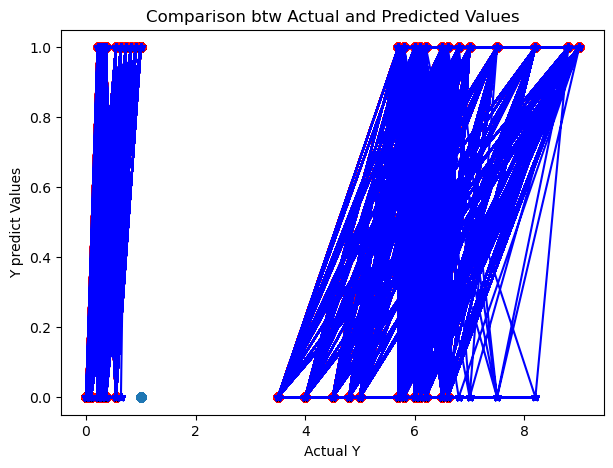

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(x_test,y_test,marker='o',c="red")
plt.plot(x_test,y_pred,marker='*',c='blue')

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Y")
plt.ylabel("Y predict Values")
plt.title("Comparison btw Actual and Predicted Values")
plt.show()

In [10]:
#2. Evaluate the model using the various performance measures
from sklearn.metrics import mean_squared_error,confusion_matrix,accuracy_score

mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)

cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

accuracy=accuracy_score(y_test,y_class)
print("Accuracy:",accuracy)

Mean Squared Error: 0.04295371814872595
Confusion Matrix:
[[17509     0]
 [  826   895]]
Accuracy: 0.957046281851274


In [11]:
#3. Classify the dataset for the given new input data HbA1c_level=8.3 and blood_glucose_level=250
import numpy as np
x_new=np.array([[8.3,250]])
y_new=model.predict(x_new)

if(y_new==1):
    print("Diabetic person")
else:
    print("Not Diabetic person")


/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Diabetic person


In [12]:
'''Ex.No. 5'''
''' 1. Consider the above diabetes data and apply kNN algorithm to predict whether a person is diabetic/non-diabetic for the following input features for “HbA1c=5 and 
blood_glucose_level-100” ''' 

X=df[['HbA1c_level','blood_glucose_level']] # taking only two features as question want to find new sample prediction on these two features only
y=df['diabetes']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(x_train,y_train)

       HbA1c_level  blood_glucose_level
46612          6.6             0.340909
31612          4.0             0.227273
96143          6.5             0.090909
95691          6.0             0.227273
37658          4.8             0.295455
...            ...                  ...
6284           6.0             0.363636
56182          5.7             0.363636
79353          6.1             0.545455
860            6.2             0.354545
15910          4.8             0.272727

[76916 rows x 2 columns] 46612    0
31612    0
96143    0
95691    0
37658    0
        ..
6284     0
56182    0
79353    0
860      0
15910    0
Name: diabetes, Length: 76916, dtype: int64


In [13]:
from sklearn.neighbors import KNeighborsClassifier
# k value is considered as 7
#Use the Euclidean distance to find the neighbourhood points
model=KNeighborsClassifier(n_neighbors=7,metric='euclidean')

model.fit(x_train,y_train)

y_pred=model.predict(x_test)
print(y_pred)

[0 0 1 ... 0 0 0]


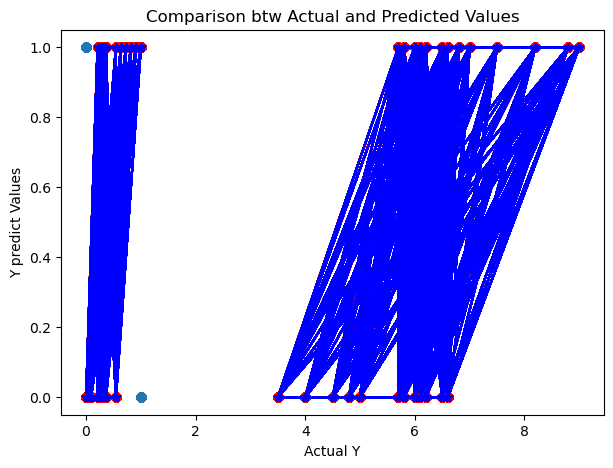

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(x_test,y_test,marker='o',c="red")
plt.plot(x_test,y_pred,marker='*',c='blue')

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Y")
plt.ylabel("Y predict Values")
plt.title("Comparison btw Actual and Predicted Values")
plt.show()

In [15]:
# Evaluate the model using the various performance measures
from sklearn.metrics import mean_squared_error,confusion_matrix,accuracy_score

mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)

cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

accuracy=accuracy_score(y_test,y_class)
print("Accuracy:",accuracy)

Mean Squared Error: 0.035517420696827874
Confusion Matrix:
[[17385   124]
 [  559  1162]]
Accuracy: 0.957046281851274


In [16]:
# for new sample prediction
x_new=np.array([[5,100]])
y_new=model.predict(x_new)

if(y_new==1):
    print("Diabetic person")
else:
    print("Not Diabetic person")


/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Diabetic person


In [17]:
'''Ex.No. 6'''

X=df.drop('diabetes',axis=1)
y=df['diabetes']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(x_train.head())
print(y_train.head())

       gender   age  hypertension  heart_disease  smoking_history    bmi  \
46612       0  35.0             0              0                1  31.53   
31612       0   0.4             0              0                1  15.19   
96143       0  60.0             0              0                4  20.90   
95691       1  66.0             0              0                0  27.05   
37658       1  48.0             0              0                2  24.05   

       HbA1c_level  blood_glucose_level  
46612          6.6             0.340909  
31612          4.0             0.227273  
96143          6.5             0.090909  
95691          6.0             0.227273  
37658          4.8             0.295455  
46612    0
31612    0
96143    0
95691    0
37658    0
Name: diabetes, dtype: int64


In [18]:
# Evaluate the model using the test dataset and visualize the pattern using decision tree
from sklearn.tree import DecisionTreeClassifier,plot_tree
model=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
model.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


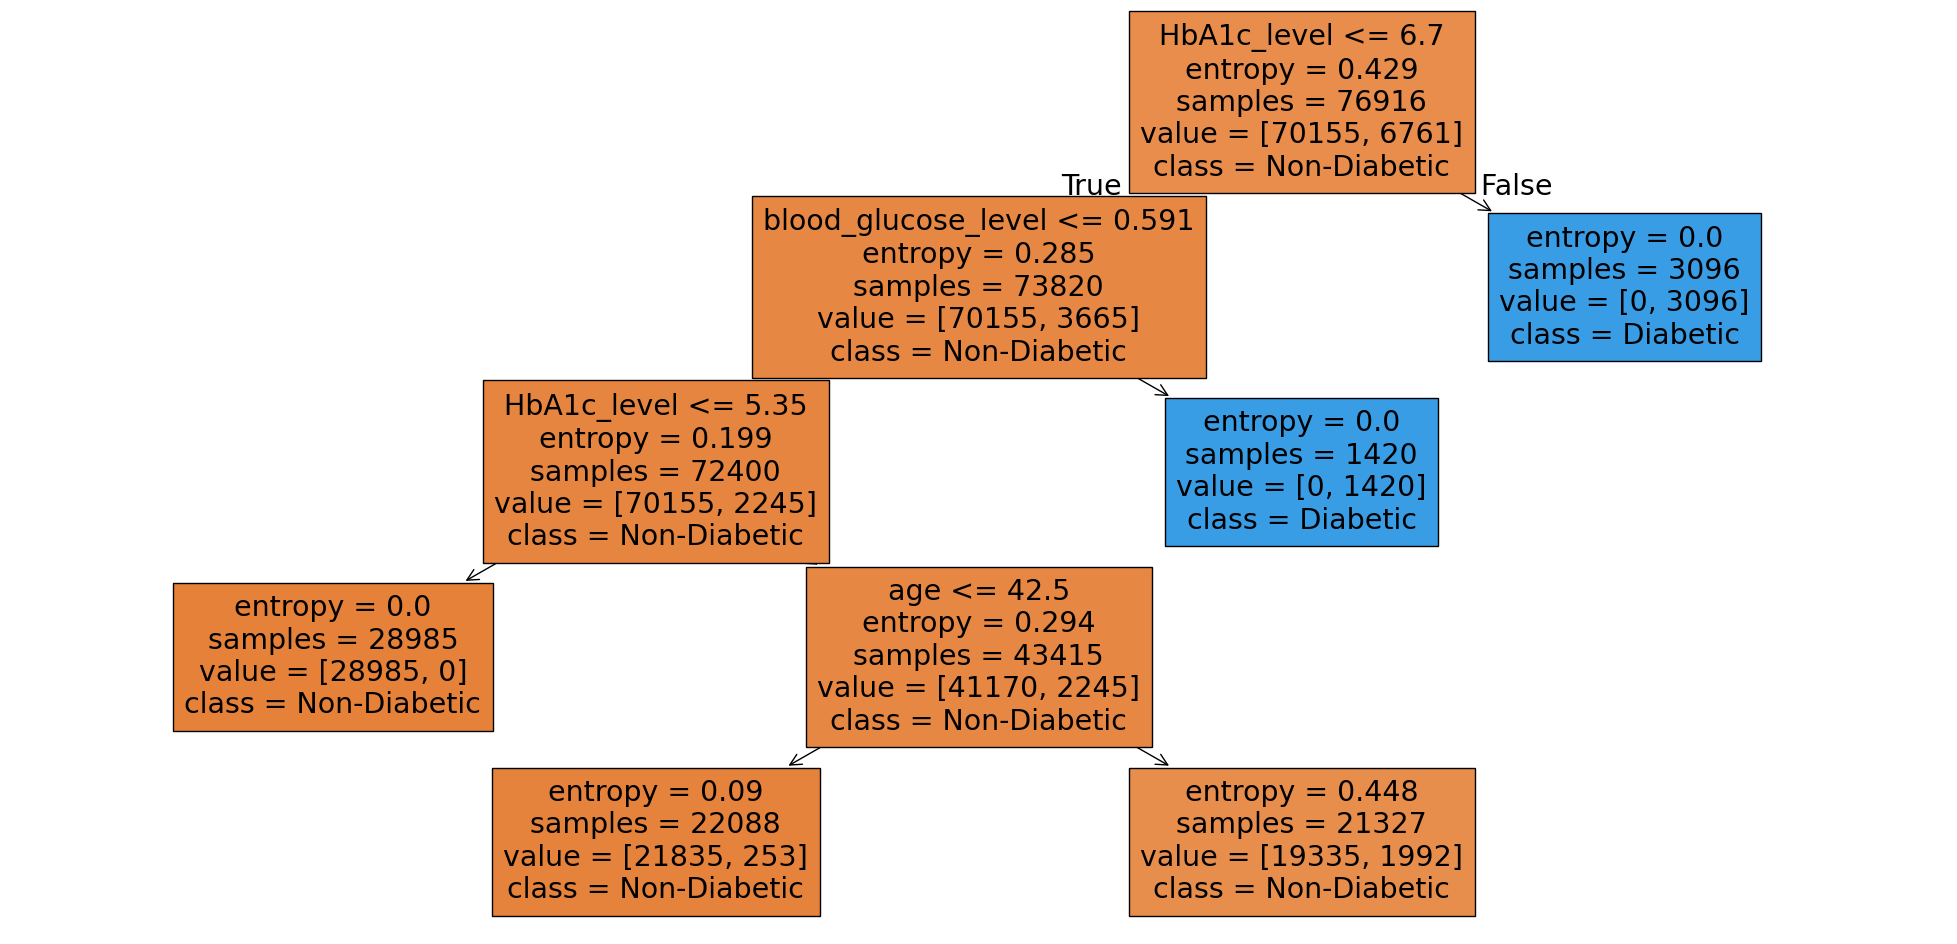

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25,12))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Non-Diabetic','Diabetic'],
          filled=True)

plt.show()


In [ ]:
#3. Explain the decision tree in text cell
'''The decision tree uses Information Gain (Entropy) to split the dataset.

The root node is selected based on the feature that gives maximum reduction in entropy.

In this dataset, important splitting features are:

HbA1c_level

blood_glucose_level

age

For example:

If HbA1c_level ≤ 6.7 → Check for Blood GLucose level
If HbA1c_level > 6.7 → Mostly Diabetic

If blood_glucose_level > 140 → Diabetic

Thus, the model works like a sequence of IF-ELSE conditions.'''

In [21]:
#4. Print the accuracy of the model and confusion matrix for the model built
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.970566822672907

Confusion Matrix:

[[17509     0]
 [  566  1155]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       1.00      0.67      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [22]:
#5. Predict the person is diabetic or not for the new input feature “Male, 80, 0, 0, never, 22.06, 9, 155”

import numpy as np

new_person = np.array([[1, 80, 0, 0, 0, 22.06, 9, 155]])

prediction = model.predict(new_person)

if prediction[0] == 1:
    print("Person is Diabetic")
else:
    print("Person is Non-Diabetic")


/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Person is Diabetic
